# Static UMAP Plotting with Cross-Matched Sample Overlays

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from pathlib import Path
import logging
import hyrax

#import nbimporter
import static_umap_plotting as sup

In [2]:
def load_external_catalog(catalog_path: str) -> pd.DataFrame:
    """Load an overlay catalog from parquet or FITS.

    Parameters
    ----------
    catalog_path : str
        Path to the catalog file.

    Returns
    -------
    pd.DataFrame
        DataFrame containing catalog rows and columns.
    """
    catalog_path = Path(catalog_path)
    suffix = catalog_path.suffix.lower()

    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(catalog_path)

    if suffix in {".fits", ".fit", ".fts"}:
        from astropy.table import Table

        return Table.read(catalog_path).to_pandas()

    raise ValueError(
        f"Unsupported catalog format '{suffix}'. Use parquet or FITS."
    )


def _resolve_catalog_id_column(catalog: pd.DataFrame, catalog_id_column: str = None) -> str:
    """Pick the catalog object-ID column, preferring user input when provided."""
    candidates = []
    if catalog_id_column is not None:
        candidates.append(catalog_id_column)

    candidates.extend([
        'object_id',
        'rubin_object_id',
        'objectId',
        'objectId_data',
        'id',
    ])

    for candidate in candidates:
        if candidate in catalog.columns:
            return candidate

    raise KeyError(
        "Could not find an object ID column in catalog. "
        "Pass catalog_id_column explicitly."
    )


def _normalize_object_ids(values) -> pd.Series:
    """Normalize object IDs to comparable string values."""
    ids = pd.Series(values, copy=False)
    ids = ids.map(
        lambda value: value.decode('utf-8')
        if isinstance(value, (bytes, bytearray))
        else value
    )

    numeric = pd.to_numeric(ids, errors='coerce')
    non_null = ids.notna()

    if non_null.any() and numeric[non_null].notna().all():
        return numeric.astype('Int64').astype(str)

    return ids.astype(str).str.strip()


In [3]:
def get_umap_with_ids(config=None, input_dir=None, suppress_logs=True, id_field: str = 'objectId_data'):
    """
    Load UMAP results and return coordinates with object IDs.

    Parameters
    ----------
    config : object
        Hyrax config object.
    input_dir : str or Path, optional
        Directory containing UMAP results.
    suppress_logs : bool, default True
        If True, suppress hyrax logging output.
    id_field : str, default 'objectId_data'
        Metadata field containing object IDs. Falls back to common alternatives
        if this field is not available.

    Returns
    -------
    dict
        Dictionary with keys:
        - 'x': array of UMAP x coordinates
        - 'y': array of UMAP y coordinates
        - 'rubin_ids': array of object IDs
        - 'id_field': metadata field used for IDs
        - 'umap_results': the InferenceDataSet object
    """
    from hyrax.data_sets.inference_dataset import InferenceDataSet

    if suppress_logs:
        logging.disable(logging.CRITICAL)

    umap_results = InferenceDataSet(config, results_dir=input_dir, verb="umap")

    logging.disable(logging.NOTSET)

    # Extract 2D coordinates
    points = np.array([point.numpy() for point in umap_results])
    x, y = points[:, 0], points[:, 1]

    # Resolve the metadata field that stores object IDs
    available_fields = umap_results.metadata_fields()
    if id_field not in available_fields:
        fallback_fields = [
            'objectId_data',
            'object_id',
            'objectId',
            'rubin_object_id',
            'id',
        ]
        id_field = next((field for field in fallback_fields if field in available_fields), None)

        if id_field is None:
            raise ValueError(
                "Could not find an object-ID metadata field in UMAP results. "
                f"Available fields: {available_fields}"
            )

    all_indices = list(range(len(umap_results)))
    metadata = umap_results.metadata(all_indices, [id_field])
    rubin_ids = np.array(metadata[id_field])

    return {
        'x': x,
        'y': y,
        'rubin_ids': rubin_ids,
        'id_field': id_field,
        'umap_results': umap_results,
    }


In [4]:
def plot_umap_with_overlay(
    ax,
    umap_data: dict,
    catalog: pd.DataFrame,
    key: str,
    threshold: float = 0.0,
    catalog_id_column: str = None,
    alpha_background: float = 0.1,
    alpha_overlay: float = 1.0,
    s_background: float = 1,
    s_overlay: float = 20,
    marker_overlay: str = 'x',
    cmap: str = 'Spectral',
    vmin: float = None,
    vmax: float = None,
    log_colorbar: bool = False,
    title: str = None,
    show_colorbar: bool = True,
):
    """
    Plot UMAP with an overlay filtered by one catalog key.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axis to plot on.
    umap_data : dict
        Dictionary from get_umap_with_ids() containing 'x', 'y', 'rubin_ids'.
    catalog : pd.DataFrame
        Catalog with object IDs and overlay columns.
    key : str
        Column name in catalog to filter/color by.
    threshold : float, default 0.0
        Minimum value of `key` for a sample to be included in overlay.
    catalog_id_column : str, optional
        Object-ID column in catalog. If None, auto-detected.
    alpha_background : float, default 0.1
        Transparency for background (non-matched) points.
    alpha_overlay : float, default 1.0
        Transparency for overlay (matched) points.
    s_background : float, default 1
        Marker size for background points.
    s_overlay : float, default 20
        Marker size for overlay points.
    marker_overlay : str, default 'x'
        Marker style for overlay points.
    cmap : str, default 'Spectral'
        Colormap for overlay points (colored by key value).
    vmin : float, optional
        Minimum value for color scaling.
    vmax : float, optional
        Maximum value for color scaling.
    log_colorbar : bool, default False
        If True, use logarithmic color scaling.
    title : str, optional
        Plot title.
    show_colorbar : bool, default True
        If True, display a colorbar.

    Returns
    -------
    matplotlib.axes.Axes
        The axis object with the plot.
    """
    x = umap_data['x']
    y = umap_data['y']
    rubin_ids = umap_data['rubin_ids']

    # Plot background (all UMAP points)
    ax.scatter(x, y, alpha=alpha_background, s=s_background, c='gray', label='All')

    if key not in catalog.columns:
        raise KeyError(f"Catalog column '{key}' not found. Available columns: {list(catalog.columns)}")

    catalog_id_column = _resolve_catalog_id_column(catalog, catalog_id_column)

    overlay_values = pd.to_numeric(catalog[key], errors='coerce')
    catalog_filtered = catalog.loc[overlay_values >= threshold, [catalog_id_column]].copy()
    catalog_filtered[key] = overlay_values.loc[catalog_filtered.index]

    if catalog_filtered.empty:
        if title:
            ax.set_title(title)
        return ax

    umap_lookup = pd.DataFrame({
        'x': x,
        'y': y,
        '_match_id': _normalize_object_ids(rubin_ids),
    })

    catalog_filtered['_match_id'] = _normalize_object_ids(catalog_filtered[catalog_id_column])
    catalog_filtered = catalog_filtered.loc[catalog_filtered['_match_id'].notna()]

    matched = catalog_filtered.merge(umap_lookup, on='_match_id', how='inner')

    if matched.empty:
        if title:
            ax.set_title(title)
        return ax

    matched_values = matched[key].to_numpy(dtype=float)

    # Set up color normalization
    if log_colorbar:
        if np.any(matched_values <= 0):
            min_positive = (
                np.min(matched_values[matched_values > 0])
                if np.any(matched_values > 0)
                else 1e-10
            )
            matched_values = np.maximum(matched_values, min_positive)
        norm = LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    # Plot overlay
    scatter = ax.scatter(
        matched['x'].to_numpy(),
        matched['y'].to_numpy(),
        alpha=alpha_overlay,
        s=s_overlay,
        c=matched_values,
        cmap=cmap,
        norm=norm,
        marker=marker_overlay,
        label=f'{key} >= {threshold}',
    )

    if show_colorbar:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label(key)

    if title:
        ax.set_title(title)

    return ax


In [5]:
def plot_umap_with_multi_overlay(
    ax,
    umap_data: dict,
    catalog: pd.DataFrame,
    overlays: list,
    catalog_id_column: str = None,
    alpha_background: float = 0.1,
    s_background: float = 1,
    title: str = None,
    show_legend: bool = True,
):
    """
    Plot UMAP with multiple overlays from different catalog keys.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axis to plot on.
    umap_data : dict
        Dictionary from get_umap_with_ids() containing 'x', 'y', 'rubin_ids'.
    catalog : pd.DataFrame
        Catalog with object IDs and overlay columns.
    overlays : list of dict
        Each dict specifies overlay properties:
        - 'key': str - column name in catalog
        - 'threshold': float - minimum value for inclusion
        - 'color': str - color for markers
        - 'marker': str - marker style
        - 'label': str - legend label
        - 's': float (optional) - marker size, default 20
        - 'alpha': float (optional) - transparency, default 1.0
    catalog_id_column : str, optional
        Object-ID column in catalog. If None, auto-detected.
    alpha_background : float, default 0.1
        Transparency for background (non-matched) points.
    s_background : float, default 1
        Marker size for background points.
    title : str, optional
        Plot title.
    show_legend : bool, default True
        If True, display a legend.

    Returns
    -------
    matplotlib.axes.Axes
        The axis object with the plot.
    """
    x = umap_data['x']
    y = umap_data['y']
    rubin_ids = umap_data['rubin_ids']

    # Plot background (all UMAP points)
    ax.scatter(x, y, alpha=alpha_background, s=s_background, c='gray', label='All')

    catalog_id_column = _resolve_catalog_id_column(catalog, catalog_id_column)

    umap_lookup = pd.DataFrame({
        'x': x,
        'y': y,
        '_match_id': _normalize_object_ids(rubin_ids),
    })

    # Plot each overlay
    for overlay in overlays:
        key = overlay['key']
        threshold = overlay.get('threshold', 0.0)
        color = overlay['color']
        marker = overlay['marker']
        label = overlay['label']
        s = overlay.get('s', 20)
        alpha = overlay.get('alpha', 1.0)

        if key not in catalog.columns:
            print(f"Warning: Catalog column '{key}' not found. Skipping.")
            continue

        overlay_values = pd.to_numeric(catalog[key], errors='coerce')
        catalog_filtered = catalog.loc[overlay_values >= threshold, [catalog_id_column]].copy()

        if catalog_filtered.empty:
            continue

        catalog_filtered['_match_id'] = _normalize_object_ids(catalog_filtered[catalog_id_column])
        catalog_filtered = catalog_filtered.loc[catalog_filtered['_match_id'].notna()]

        matched = catalog_filtered.merge(umap_lookup, on='_match_id', how='inner')

        if matched.empty:
            continue

        # Plot overlay
        ax.scatter(
            matched['x'].to_numpy(),
            matched['y'].to_numpy(),
            alpha=alpha,
            s=s,
            c=color,
            marker=marker,
            label=label,
        )

    if show_legend:
        ax.legend(loc='best', fontsize='small')

    if title:
        ax.set_title(title)

    return ax


In [6]:
def plot_multiple_umaps_with_overlay(
    runs,
    expts,
    catalog: pd.DataFrame,
    key: str,
    threshold: float = 0.0,
    catalog_id_column: str = None,
    ncols: int = 3,
    figsize: tuple = None,
    dpi: int = 150,
    save_path: str = None,
    suptitle: str = None,
    suppress_logs: bool = True,
    **kwargs
):
    """
    Create multi-panel UMAP plots with catalog overlays.

    Parameters
    ----------
    runs : array-like
        Array of run numbers.
    expts : array-like
        Array of experiment numbers (same length as runs).
    catalog : pd.DataFrame
        Catalog with object IDs and overlay columns.
    key : str
        Column name in catalog to filter/color by.
    threshold : float, default 0.0
        Minimum value of `key` for a sample to be included in overlay.
    catalog_id_column : str, optional
        Object-ID column in catalog. If None, auto-detected.
    ncols : int, default 3
        Number of columns in the subplot grid.
    figsize : tuple, optional
        Figure size. If None, calculated based on number of plots.
    dpi : int, default 150
        DPI for the figure.
    save_path : str or Path, optional
        Path to save the plot. If None, just displays it.
    suptitle : str, optional
        Overall figure title.
    suppress_logs : bool, default True
        If True, suppress hyrax logging output.
    **kwargs
        Additional keyword arguments passed to plot_umap_with_overlay.

    Returns
    -------
    matplotlib.figure.Figure
        The matplotlib figure object.
    """
    import math
    import hyrax
    from tqdm.notebook import tqdm

    if len(runs) != len(expts):
        raise ValueError("runs and expts arrays must be the same length")

    n_plots = len(runs)
    nrows = math.ceil(n_plots / ncols)

    if figsize is None:
        figsize = (ncols * 4, nrows * 3)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, dpi=dpi)

    # Handle different subplot configurations
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (run, expt) in enumerate(tqdm(zip(runs, expts), total=len(expts))):
        if i >= len(axes):
            break

        ax = axes[i]

        try:
            # Get UMAP info and create config
            umap_dir, config_file = sup.extract_umap_info(run, expt)

            if suppress_logs:
                logging.disable(logging.CRITICAL)
            h = hyrax.Hyrax(config_file=config_file)
            logging.disable(logging.NOTSET)

            # Get UMAP data with IDs
            umap_data = get_umap_with_ids(config=h.config, input_dir=umap_dir, suppress_logs=suppress_logs)

            # Create title
            title = f"Run {run}, Expt {expt}"

            # Plot with overlay
            plot_umap_with_overlay(
                ax,
                umap_data,
                catalog,
                key,
                threshold=threshold,
                catalog_id_column=catalog_id_column,
                title=title,
                **kwargs,
            )

        except Exception as e:
            ax.text(0.5, 0.5, f"Error loading\nRun {run}, Expt {expt}\n{str(e)}",
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"Run {run}, Expt {expt} - ERROR")

    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].axis('off')

    if suptitle:
        fig.suptitle(suptitle, fontsize=16)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    else:
        plt.show()

    return fig


In [7]:
def plot_multiple_umaps_with_multi_overlay(
    runs,
    expts,
    catalog: pd.DataFrame,
    overlays: list,
    catalog_id_column: str = None,
    ncols: int = 3,
    figsize: tuple = None,
    dpi: int = 150,
    save_path: str = None,
    suptitle: str = None,
    suppress_logs: bool = True,
    alpha_background: float = 0.1,
    s_background: float = 1,
    show_legend: bool = True,
):
    """
    Create multi-panel UMAP plots with multiple catalog overlays per panel.

    Parameters
    ----------
    runs : array-like
        Array of run numbers.
    expts : array-like
        Array of experiment numbers (same length as runs).
    catalog : pd.DataFrame
        Catalog with object IDs and overlay columns.
    overlays : list of dict
        Each dict specifies overlay properties:
        - 'key': str - column name in catalog
        - 'threshold': float - minimum value for inclusion
        - 'color': str - color for markers
        - 'marker': str - marker style
        - 'label': str - legend label
        - 's': float (optional) - marker size, default 20
        - 'alpha': float (optional) - transparency, default 1.0
    catalog_id_column : str, optional
        Object-ID column in catalog. If None, auto-detected.
    ncols : int, default 3
        Number of columns in the subplot grid.
    figsize : tuple, optional
        Figure size. If None, calculated based on number of plots.
    dpi : int, default 150
        DPI for the figure.
    save_path : str or Path, optional
        Path to save the plot. If None, just displays it.
    suptitle : str, optional
        Overall figure title.
    suppress_logs : bool, default True
        If True, suppress hyrax logging output.
    alpha_background : float, default 0.1
        Transparency for background points.
    s_background : float, default 1
        Marker size for background points.
    show_legend : bool, default True
        If True, display legend on each panel.

    Returns
    -------
    matplotlib.figure.Figure
        The matplotlib figure object.
    """
    import math
    import hyrax
    from tqdm.notebook import tqdm

    if len(runs) != len(expts):
        raise ValueError("runs and expts arrays must be the same length")

    n_plots = len(runs)
    nrows = math.ceil(n_plots / ncols)

    if figsize is None:
        figsize = (ncols * 4, nrows * 3)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, dpi=dpi)

    # Handle different subplot configurations
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (run, expt) in enumerate(tqdm(zip(runs, expts), total=len(expts))):
        if i >= len(axes):
            break

        ax = axes[i]

        try:
            # Get UMAP info and create config
            umap_dir, config_file = sup.extract_umap_info(run, expt)

            if suppress_logs:
                logging.disable(logging.CRITICAL)
            h = hyrax.Hyrax(config_file=config_file)
            logging.disable(logging.NOTSET)

            # Get UMAP data with IDs
            umap_data = get_umap_with_ids(config=h.config, input_dir=umap_dir, suppress_logs=suppress_logs)

            # Create title
            title = f"Run {run}, Expt {expt}"

            # Plot with multi-overlay
            plot_umap_with_multi_overlay(
                ax,
                umap_data,
                catalog,
                overlays,
                catalog_id_column=catalog_id_column,
                alpha_background=alpha_background,
                s_background=s_background,
                title=title,
                show_legend=show_legend,
            )

        except Exception as e:
            ax.text(0.5, 0.5, f"Error loading\nRun {run}, Expt {expt}\n{str(e)}",
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"Run {run}, Expt {expt} - ERROR")

    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].axis('off')

    if suptitle:
        fig.suptitle(suptitle, fontsize=16)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    else:
        plt.show()

    return fig


## Example Usage

In [8]:
# Example: Load catalog from FITS
# catalog = load_external_catalog("/Users/diegomiura/research/Hyrax-Research/test_dir5/catalog.fits")

# Example: Get UMAP data
# run, expt = 10, 12
# umap_dir, config_file = sup.extract_umap_info(run, expt)
# h = hyrax.Hyrax(config_file=config_file)
# umap_data = get_umap_with_ids(config=h.config, input_dir=umap_dir)

# Example: Single overlay (numeric column)
# fig, ax = plt.subplots(figsize=(8, 6))
# plot_umap_with_overlay(ax, umap_data, catalog, key="major_count_since_1gyr", threshold=1)
# plt.show()

# Example: Multi-key overlay (boolean columns)
# fig, ax = plt.subplots(figsize=(8, 6))
# overlays = [
#     {'key': 'has_major_past_1gyr', 'threshold': 0.5, 'color': 'red', 'marker': 'x', 'label': 'Major (past 1 Gyr)'},
#     {'key': 'has_minor_past_1gyr', 'threshold': 0.5, 'color': 'blue', 'marker': 'o', 'label': 'Minor (past 1 Gyr)'},
# ]
# plot_umap_with_multi_overlay(ax, umap_data, catalog, overlays)
# plt.show()


In [9]:
catalog = load_external_catalog("/Users/diegomiura/research/Hyrax-Research/test_dir5/catalog.fits")
print(catalog.columns.tolist())


['object_id', 'filename', 'filter', 'sim', 'snapshot', 'subhalo', 'dbid', 'has_merger_row', 'has_major_past_1gyr', 'has_major_future_1gyr', 'has_minor_past_1gyr', 'has_minor_future_1gyr', 'has_mini_past_1gyr', 'has_mini_future_1gyr', 'major_count_since_1gyr', 'major_count_until_1gyr', 'minor_count_since_1gyr', 'minor_count_until_1gyr', 'mini_count_since_1gyr', 'mini_count_until_1gyr', 'major_time_since_merger', 'major_time_until_merger', 'minor_time_since_merger', 'minor_time_until_merger', 'mini_time_since_merger', 'mini_time_until_merger']


In [11]:
run, expt = 1, 1
umap_dir, config_file = sup.extract_umap_info(run, expt)
h = hyrax.Hyrax(config_file=config_file)
umap_data = get_umap_with_ids(config=h.config, input_dir=umap_dir)

FileNotFoundError: 3dumap output file not found: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/run1/udb1_1.txt

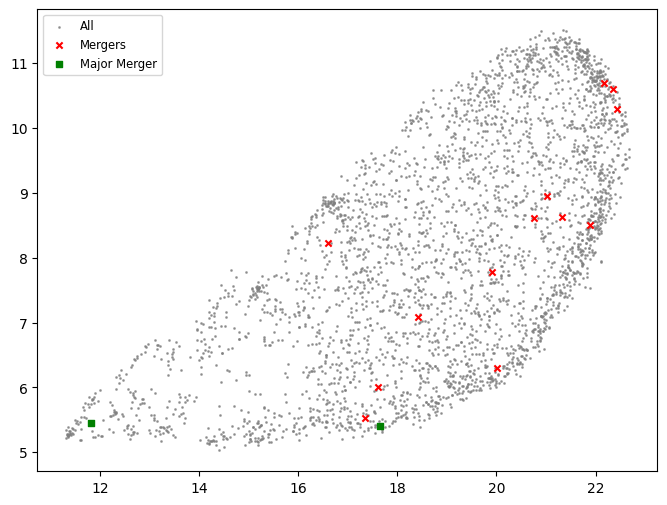

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))
overlays = [
    {'key': 'has_major_past_1gyr', 'threshold': 0.5, 'color': 'red', 'marker': 'x', 'label': 'Major (past 1 Gyr)'},
    {'key': 'has_minor_past_1gyr', 'threshold': 0.5, 'color': 'green', 'marker': 's', 'label': 'Minor (past 1 Gyr)'},
    {'key': 'has_mini_past_1gyr', 'threshold': 0.5, 'color': 'blue', 'marker': 'o', 'label': 'Mini (past 1 Gyr)'},
]
plot_umap_with_multi_overlay(ax, umap_data, catalog, overlays, alpha_background=0.7)
plt.show()


  0%|          | 0/7 [00:00<?, ?it/s]

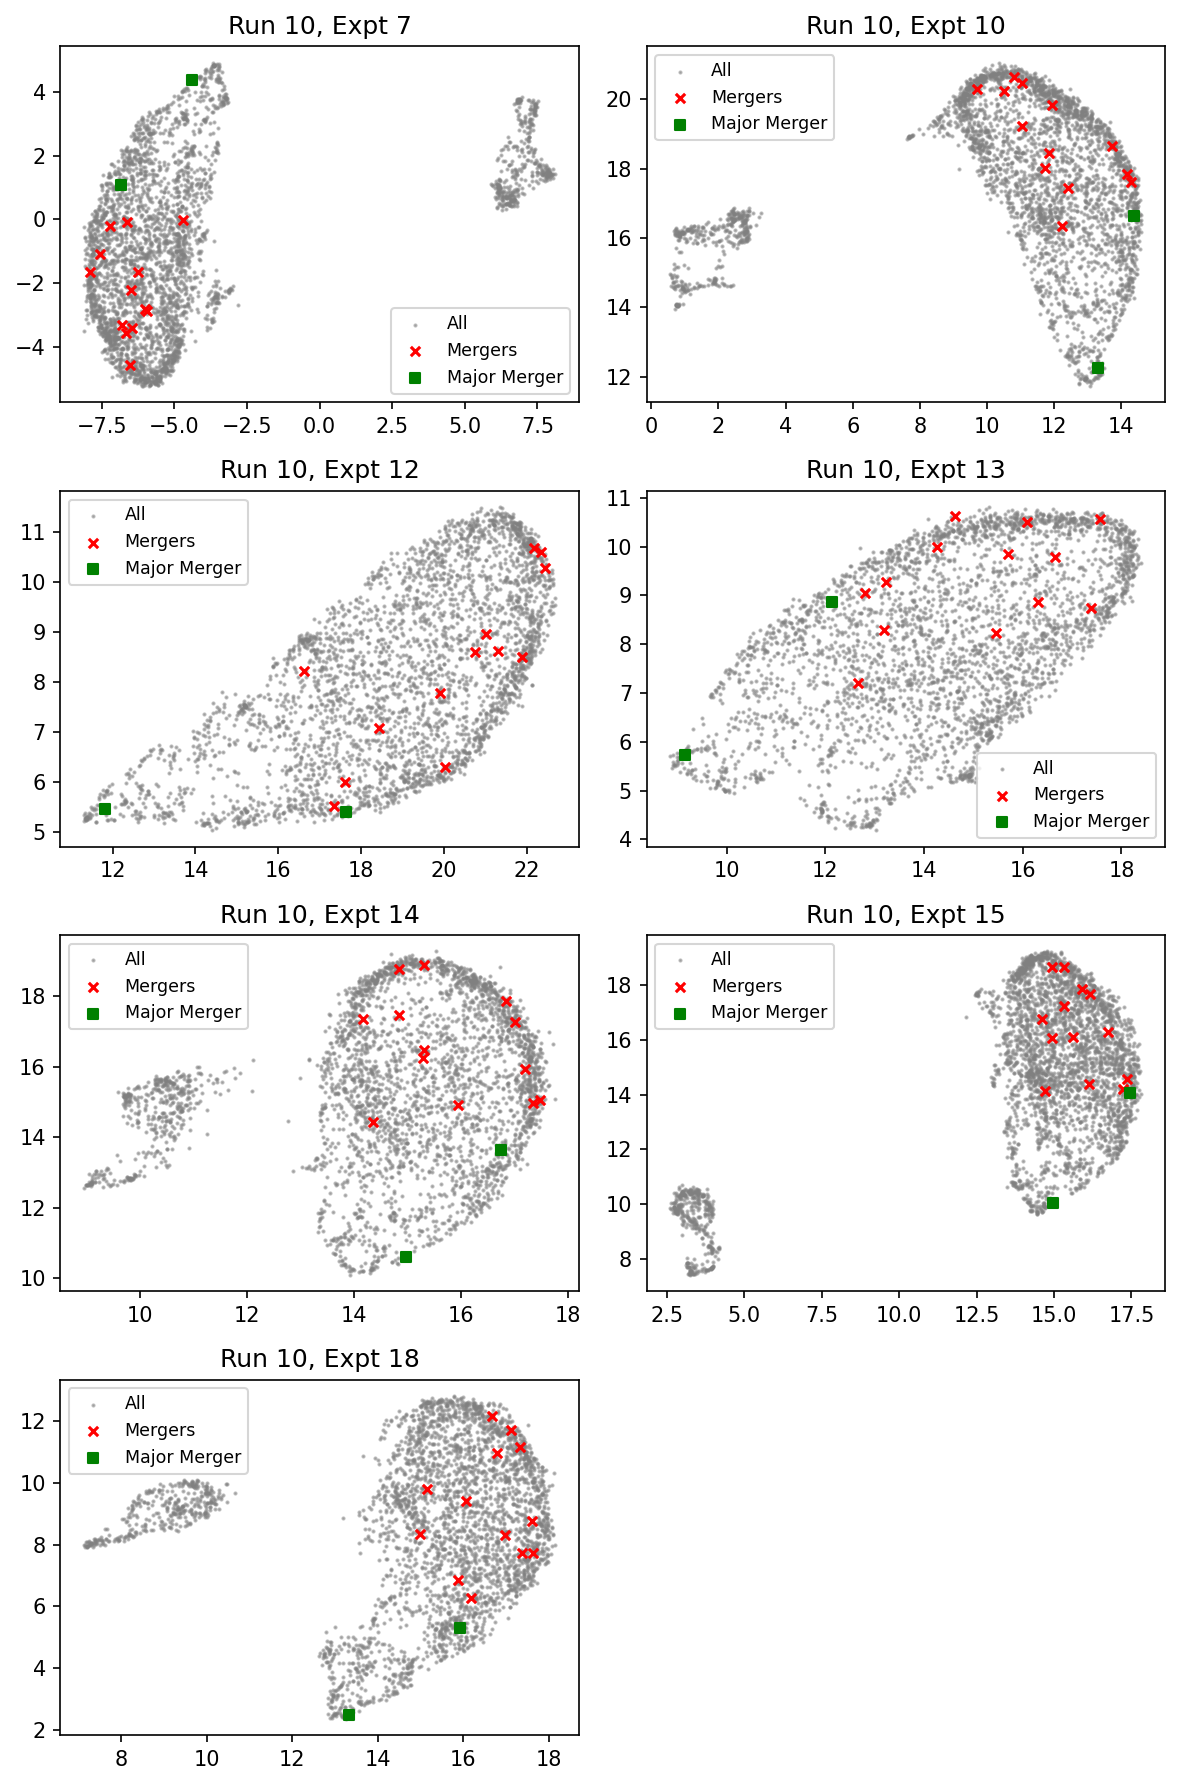

In [49]:
overlays = [
    {'key': 'has_major_past_1gyr', 'threshold': 0.5, 'color': 'red', 'marker': 'x', 'label': 'Major (past 1 Gyr)'},
    {'key': 'has_minor_past_1gyr', 'threshold': 0.5, 'color': 'green', 'marker': 's', 'label': 'Minor (past 1 Gyr)'},
    {'key': 'has_mini_past_1gyr', 'threshold': 0.5, 'color': 'blue', 'marker': 'o', 'label': 'Mini (past 1 Gyr)'},
]

expts = [7,10,12,13,14,15,18]
runs = [10]*len(expts)

fig = plot_multiple_umaps_with_multi_overlay(
    runs,
    expts,
    catalog,
    overlays,
    ncols=2,
    alpha_background=0.5,
    show_legend=True,
)
